In [2]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Install Kaggle API
!pip install kaggle -q

# Step 3: Upload your kaggle.json API key
from google.colab import files
files.upload()  # Upload your kaggle.json here

# Step 4: Set up Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Step 5: Define your target Drive folder and download the dataset there
import os

target_folder = '/content/drive/MyDrive/Receipt Information Extraction/Datasets'
os.makedirs(target_folder, exist_ok=True)

!kaggle datasets download -d urbikn/sroie-datasetv2 -p "{target_folder}" --unzip

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/urbikn/sroie-datasetv2
License(s): other
100% 834M/834M [00:33<00:00, 26.0MB/s]



In [8]:
import os
import json
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from datasets import Dataset, DatasetDict
from transformers import (
    AutoProcessor,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DefaultDataCollator
)

In [4]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATASET_DIR = "/content/drive/MyDrive/Receipt Information Extraction/Datasets/SROIE2019"
MODEL_ID = "microsoft/layoutlmv3-base"
OUTPUT_DIR = "./layoutlmv3-sroie-model"

# Flat labels based on your JSON structure
LABELS = ["O", "COMPANY", "DATE", "ADDRESS", "TOTAL"]
LABEL2ID = {label: idx for idx, label in enumerate(LABELS)}
ID2LABEL = {idx: label for idx, label in enumerate(LABELS)}

# ==========================================
# 2. THE RAM-FRIENDLY DATA PARSER
# ==========================================
def normalize_bbox(box, width, height):
    return [
        max(0, min(1000, int(1000 * (box[0] / width)))),
        max(0, min(1000, int(1000 * (box[1] / height)))),
        max(0, min(1000, int(1000 * (box[2] / width)))),
        max(0, min(1000, int(1000 * (box[3] / height)))),
    ]

def load_sroie_split(split_name):
    split_dir = os.path.join(DATASET_DIR, split_name)
    img_dir, box_dir, ent_dir = [os.path.join(split_dir, f) for f in ["img", "box", "entities"]]

    examples = {"image_path": [], "words": [], "bboxes": [], "ner_tags": []}

    for filename in os.listdir(img_dir):
        if not filename.endswith(".jpg"): continue
        file_id = filename.split(".")[0]

        img_path = os.path.join(img_dir, filename)
        box_path = os.path.join(box_dir, file_id + ".txt")
        ent_path = os.path.join(ent_dir, file_id + ".txt")

        if not (os.path.exists(box_path) and os.path.exists(ent_path)): continue

        try:
            with Image.open(img_path) as img:
                width, height = img.size

            # ADDED: errors='ignore' to bypass weird characters like the Pound sign (£)
            with open(ent_path, 'r', encoding='utf-8', errors='ignore') as f:
                entities = json.load(f)
                # print(entities)
        except Exception:
            continue

        words, bboxes, ner_tags = [], [], []

        # ADDED: errors='ignore' here as well
        with open(box_path, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                parts = line.strip().split(',')
                if len(parts) < 9: continue

                coords = [int(p) for p in parts[:8]]
                text_fragment = ",".join(parts[8:]).strip()

                x_min = min(coords[0], coords[2], coords[4], coords[6])
                y_min = min(coords[1], coords[3], coords[5], coords[7])
                x_max = max(coords[0], coords[2], coords[4], coords[6])
                y_max = max(coords[1], coords[3], coords[5], coords[7])

                if x_max <= x_min or y_max <= y_min: continue

                assigned_label = "O"
                for key, full_string in entities.items():
                    if full_string and text_fragment in full_string:
                        assigned_label = key.upper()
                        break

                words.append(text_fragment)
                bboxes.append(normalize_bbox([x_min, y_min, x_max, y_max], width, height))
                ner_tags.append(LABEL2ID[assigned_label])

        examples["image_path"].append(img_path)
        examples["words"].append(words)
        examples["bboxes"].append(bboxes)
        examples["ner_tags"].append(ner_tags)

    return Dataset.from_dict(examples)


# ==========================================
# 3. INITIALIZATION & PREPROCESSING (OOM SAFE)
# ==========================================
print("Loading and parsing raw data...")
raw_datasets = DatasetDict({
    "train": load_sroie_split("train"),
    "test": load_sroie_split("test")
})

Loading and parsing raw data...


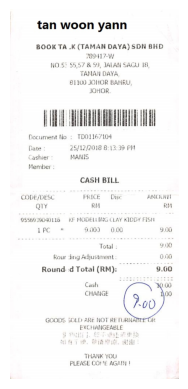

In [9]:
img = Image.open(raw_datasets['train'][0]['image_path'])
plt.imshow(img)
plt.axis('off')
plt.show()